# 卷积神经网络 Convolutional Neural Network (CNN)

CNN网络主要由三部分构成：**卷积层、池化层和全连接层**构成：

（1）卷积层负责提取图像中的局部特征

（2）池化层用来大幅降低参数量级(降维)

（3）全连接层类似人工神经网络的部分，用来输出想要的结果(只能处理二维数据)

## 卷积层

卷积层（Convolutional Layer）通过卷积操作提取输入数据中的特征（例如图像中的边缘、纹理、形状等）。
>
> 卷积层利用卷积核（滤波器）对输入进行处理，从而生成特征图（feature map），并且每个卷积层能够提取不同层次的特征，从低级特征（如边缘）到高级特征（如物体的形状）。
>
> **卷积层的主要作用如下：**
>
> - **特征提取**：卷积层的主要作用是从输入图像中提取低级特征（如边缘、角点、纹理等）。通过多个卷积层的堆叠，网络能够逐渐从低级特征到高级特征（如物体的形状、区域等）进行学习。
>
> - **权重共享**：在卷积层中，同一个卷积核在整个输入图像上共享权重，这使得卷积层的参数数量大大减少，减少了计算量并提高了训练效率。
>
> - **局部连接**：卷积层中的每个神经元仅与输入图像的一个小局部区域相连，这称为**局部感受野**，这种局部连接方式更符合图像的空间结构，有助于捕捉图像中的局部特征。
>
> - **空间不变性**：由于卷积操作是局部的并且采用权重共享，卷积层在处理图像时具有**平移不变性**。也就是说，不论物体出现在图像的哪个位置，卷积层都能有效地检测到这些物体的特征。


### Padding（填充）

通过上面的卷积计算过程，最终的特征图比原始图像小很多，如果想要保持经过卷积后的图像大小不变, 可以在**原图周围**添加 Padding 来实现。

Padding（填充）操作是一种用于==在输入特征图的边界周围添加额外像素（通常是零）==。

**Padding的主要作用：**

- **保持空间维度**：如果不使用 padding，每次卷积操作后，特征图的尺寸都会缩小。多次卷积后，特征图会变得非常小，可能会丢失重要的边缘信息。Padding可以帮助维持输出特征图的尺寸与输入相同或接近相同。
- **保留边缘信息**：图像边缘的像素在卷积过程中参与的计算次数较少，这意味着边缘信息在特征提取过程中容易丢失。Padding通过在边缘添加额外的像素，增加了边缘像素的参与度，从而更好地保留了边缘信息。
- **提高性能**：Padding有助于避免由于特征图尺寸快速缩小而导致的信息丢失，从而提高模型的性能，尤其是在处理较小的图像或需要进行多层卷积时。

**Padding的类型：**

- **Valid Padding (No Padding):** 不进行任何填充。卷积核只在输入图像的有效区域内滑动。输出尺寸会缩小。
- **Same Padding:** 添加足够的填充，使得输出特征图的尺寸与输入相同。
- **Full Padding:** 尽可能多地添加填充，使得卷积核的每个元素都至少在输入图像上滑动一次。输出尺寸会增大。


### Stride（步长）

Stride（步长）指的是**卷积核在图像上滑动时的步伐大小**，即每次卷积时卷积核在图像中向右（或向下）移动的像素数。步长直接影响卷积操作后输出特征图的尺寸，以及计算量和模型的特征提取能力。

**Stride的作用:**

- **降低计算复杂度**：更大的步长意味着卷积核移动的次数更少，从而减少了计算量，并加快了训练和推理速度。
- **步长越大，生成的特征图尺寸越小。这类似于池化的降维效果。
- **增大感受野**：虽然更大的步长会减小特征图的尺寸，但它同时也会增大每个神经元在输入数据上的感受野。这意味着每个神经元能够捕捉到更大范围的输入信息。

**Stride的选择**：取决于具体的应用场景和网络架构

- **Stride = 1:** 这是最常见的设置，尤其是在网络的早期层。它允许保留更多的空间细节。
- **Stride > 1:** 通常用于减小特征图的尺寸和增大感受野，例如在网络的后期层或需要进行快速降维时。 常见的设置包括 stride=2 或 stride=4。

### 多通道卷积运算

1. 当输入有多个通道(Channel), 例如 RGB 三个通道, 此时要求卷积核需要拥有相同的通道数（图像有多少通道，每个卷积核就有多少通道）.
2. 每个卷积核通道与对应的输入图像的各个通道进行卷积.
3. 将每个通道的卷积结果按位相加得到最终的特征图.

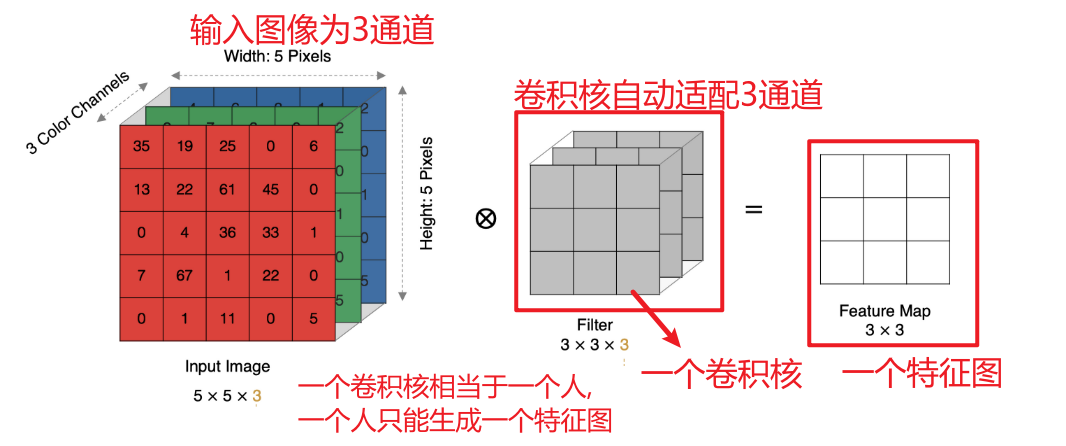

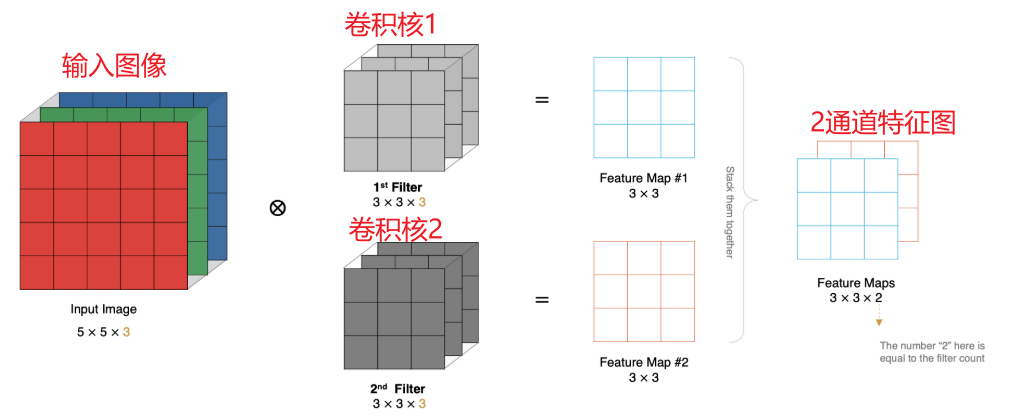

In [33]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 处理png转jpg的问题
img = plt.imread('./data/img.jpg')
print(f'img.type: {type(img)}, shape: {img.shape}')
img = torch.from_numpy(img)
print(f'img.type: {img.type}, shape: {img.shape}')
img = img.permute(2, 0, 1)
img = img[:3, :, :]
print(f'img.type: {img.type}, shape: {img.shape}')
img = img.permute(1, 2, 0).numpy()
plt.imsave('./data/img1.jpg', img, format = 'jpeg')

img.type: <class 'numpy.ndarray'>, shape: (640, 640, 4)
img.type: <built-in method type of Tensor object at 0x0000024BD3E355D0>, shape: torch.Size([640, 640, 4])
img.type: <built-in method type of Tensor object at 0x0000024BD3E02E80>, shape: torch.Size([3, 640, 640])


img.type: <class 'numpy.ndarray'>, shape: (640, 640, 3)
img2.type: <built-in method type of Tensor object at 0x0000024BD3928540>, shape: torch.Size([3, 640, 640])
img3.type: <built-in method type of Tensor object at 0x0000024BD4C0B1F0>, shape: torch.Size([1, 3, 640, 640])
conv_ing.type: <built-in method type of Tensor object at 0x0000024BD40A0F90>, shape: torch.Size([1, 4, 319, 319])


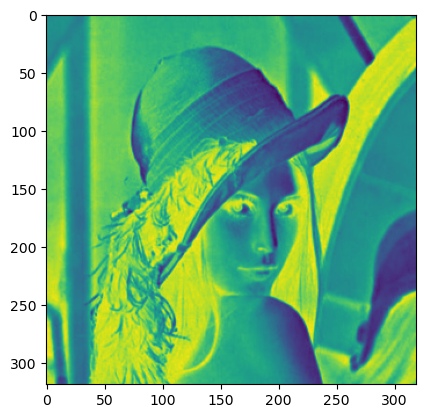

In [34]:
 img = plt.imread('./data/img1.jpg')
 print(f'img.type: {type(img)}, shape: {img.shape}')

 img2 = torch.tensor(img, dtype = torch.float)
 img2 = img2.permute(2, 0, 1)
 print(f'img2.type: {img2.type}, shape: {img2.shape}')

 # 只有一张图，增加一个维度 CHW -> (1, C, H, W) 一张三通道的640 * 640 图片
 img3 = img2.unsqueeze(dim = 0)
 print(f'img3.type: {img3.type}, shape: {img3.shape}')

 # 输入通道数，输出通道数(几个特征图)，卷积核大小，步长，填充
 conv = nn.Conv2d(in_channels = 3, out_channels = 4, kernel_size = 3, stride = 2, padding = 0)
 conv_ing = conv(img3)
 print(f'conv_ing.type: {conv_ing.type}, shape: {conv_ing.shape}')

 # 转回去
 img4 = conv_ing[0]
 img5 = img4.permute(1, 2, 0)
 feature2 = img5[:, :, 2].detach().numpy()
 plt.imshow(feature2)
 plt.show()


## 池化层：不改变通道数

> 池化层（Pooling Layer）是用于降低输入数据的空间维度（例如图像的高度和宽度），从而减少计算量、减少内存消耗，并提高模型的鲁棒性。
>
> 池化层通常位于卷积层之后，它通过对卷积层输出的特征图进行下采样，保留最重要的特征信息，同时丢弃一些不重要的细节。
>
> **池化层的主要作用如下:**
>
> - **降维和计算量减少**：池化层通过减少特征图的尺寸，从而降低了计算量，特别是在多层网络中，随着层数的增加，池化能够显著减少计算资源的消耗。
>
> - **提高鲁棒性**：池化操作可以使得特征对小的变换、平移和旋转变得更加不敏感。这样，模型在面对噪声或图像的轻微变化时，依然能够稳定工作。
>
> - **防止过拟合**：通过池化减少了特征图的大小，减少了模型的复杂度，从而有助于防止过拟合，尤其是在较小的数据集上。
>
> - **抽象特征**：通过池化层的操作，可以提取更为抽象和高层次的特征，使得网络能够学习到更具泛化能力的表示。

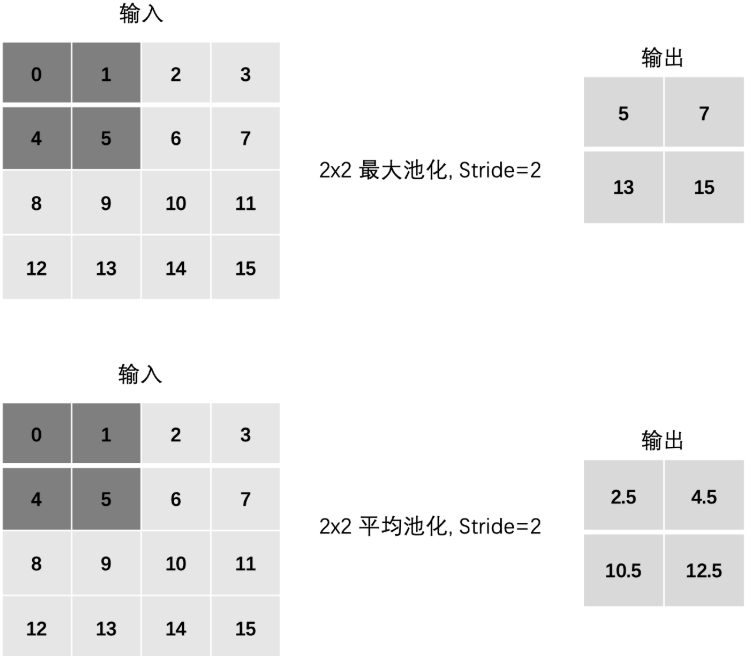

In [38]:
inputs = torch.tensor([
    [
        [0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]
    ],
    [
        [10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]
    ],
    [
        [11, 22, 33],
        [44, 55, 66],
        [77, 88, 99]
    ]
])
print(f'inputs:{inputs}, inputs.shape: {inputs.shape}')

pool1 = nn.MaxPool2d(kernel_size = 2, stride = 1, padding = 0)
outputs = pool1(inputs)
print(f'outputs:{outputs}, outputs.shape: {outputs.shape}')

pool2 = nn.AvgPool2d(kernel_size = 2, stride = 1, padding = 0)
outputs = pool2(inputs)
print(f'outputs:{outputs}, outputs.shape: {outputs.shape}')

inputs:tensor([[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8]],

        [[10, 20, 30],
         [40, 50, 60],
         [70, 80, 90]],

        [[11, 22, 33],
         [44, 55, 66],
         [77, 88, 99]]]), inputs.shape: torch.Size([3, 3, 3])
outputs:tensor([[[ 4,  5],
         [ 7,  8]],

        [[50, 60],
         [80, 90]],

        [[55, 66],
         [88, 99]]]), outputs.shape: torch.Size([3, 2, 2])
outputs:tensor([[[ 2,  3],
         [ 5,  6]],

        [[30, 40],
         [60, 70]],

        [[33, 44],
         [66, 77]]]), outputs.shape: torch.Size([3, 2, 2])


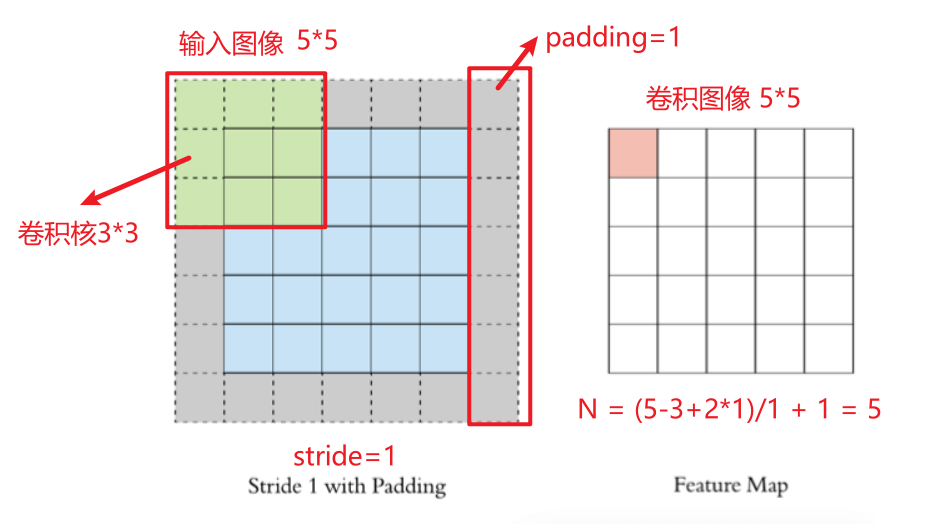